# NLP HuggingFace Model With Probabilities based off of Plutchick Models

The [Plutchik Model of Emotions](https://pmc.ncbi.nlm.nih.gov/articles/PMC8409663/) is a popular basis for emotion visualization. Thus, a classification model based off this model could help give people insight into their emotions. We'll use a DistilBERT model due it's simplicity as a base, evaluate our model on test data and then build a function that uses a sigmoid activation function to calculate probabilities

We strongly ecouraging using a free GPU on Colab as training time is incredibly slow wiithout it

In [1]:
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix, ConfusionMatrixDisplay
from transformers import AutoModelForSequenceClassification, AutoTokenizer, EvalPrediction, TrainingArguments, Trainer, TrainerCallback

from datasets import Dataset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
import torch
import torch.nn as nn
import torch.nn.functional as F

import warnings
warnings.filterwarnings('ignore')

In [2]:
df1 = pd.read_parquet("hf://datasets/hemanthkotaprolu/goemotions-plutchiks/data/train-00000-of-00001.parquet")
# Neccesaary Downstream
df1 = df1.rename({"label": "labels"}, axis = 1)
df1

,input,labels
0,My favourite food is anything I didn't have to...,neutral
1,"Now if he does off himself, everyone will thin...",neutral
2,WHY THE FUCK IS BAYLESS ISOING,anger
3,To make her feel threatened,fear
4,Dirty Southern Wankers,anger
...,...,...
51580,"The last time it happened I just said, ""No"" an...",sadness
51581,"The last time it happened I just said, ""No"" an...",surprise
51582,I can’t stand this arrogant prick he’s no bett...,anger
51583,::but I like baby bangs:: /tiny voice,joy


In [3]:
df2 = pd.read_csv("hf://datasets/uavster/Llama3_8b-emotion_multiclass-Plutchik/emotions_llama3-8b-4bit_6540rows_robust07-filtered.csv", header = None)
df2 = df2.rename({0:"input"}, axis = 1)
df2

,input
0,"I just got tickets to my favorite concert.;""joy"""
1,"I finally got a promotion at work.;""joy"""
2,"I got a surprise visit from my best friend.;""joy"""
3,My favorite book series is being adapted into ...
4,I just finished a difficult project and I feel...
...,...
6535,"My favorite food is pizza, but I also eat othe..."
6536,I don't have any strong feelings about this ne...
6537,"I'm okay with going to the movies tonight.;""ne..."
6538,I don't really have an opinion on that matter....


In [4]:
# Extract label from str
def extract_word_in_quotes(text):
  """
  Get quotation label from string in dataframe if it's one of words in sent9
  """
  sent9= ['joy' ,'sadness', 'trust', 'disgust' ,'fear' ,'anger', 'surprise', 'anticipation', 'neutral']
  match = re.findall(r'\;"([^"]*)"', text)
  extracted_words = [word for word in match if word in sent9]

  return extracted_words[0] if extracted_words else "None"


df2['labels'] = df2['input'].apply(extract_word_in_quotes)
# Remove label from str

def remove_label(text):
  sent9= ['joy' ,'sadness', 'trust', 'disgust' ,'fear' ,'anger', 'surprise', 'anticipation', 'neutral']
  for label in sent9:
    text = re.sub(rf";\"\b{label}\b\"$", "", text).strip()
  return text

df2['input'] = df2['input'].apply(lambda x: remove_label(x))

# Sanity Check
df2['labels'].value_counts()

,count
labels,
anticipation,946
disgust,838
neutral,812
sadness,748
anger,743
trust,735
joy,611
fear,579
surprise,528


In [5]:
df2

,input,labels
0,I just got tickets to my favorite concert.,joy
1,I finally got a promotion at work.,joy
2,I got a surprise visit from my best friend.,joy
3,My favorite book series is being adapted into ...,joy
4,I just finished a difficult project and I feel...,joy
...,...,...
6535,"My favorite food is pizza, but I also eat othe...",neutral
6536,I don't have any strong feelings about this ne...,neutral
6537,I'm okay with going to the movies tonight.,neutral
6538,I don't really have an opinion on that matter.,neutral


In [6]:
df_final = pd.concat([df1, df2]).reset_index(drop=True)
df_final

,input,labels
0,My favourite food is anything I didn't have to...,neutral
1,"Now if he does off himself, everyone will thin...",neutral
2,WHY THE FUCK IS BAYLESS ISOING,anger
3,To make her feel threatened,fear
4,Dirty Southern Wankers,anger
...,...,...
58120,"My favorite food is pizza, but I also eat othe...",neutral
58121,I don't have any strong feelings about this ne...,neutral
58122,I'm okay with going to the movies tonight.,neutral
58123,I don't really have an opinion on that matter.,neutral


# Loading Model

In [7]:
model_name = "distilbert-base-uncased"  # Arbitrary
# Extract unqiue Labels and aLphabetize
unique_labels = df_final['labels'].unique()
# Alphabetize
unique_labels = sorted(unique_labels)
# Put neutral at the end. Easier later
unique_labels.remove('neutral')
unique_labels.append('neutral')

num_labels = len(unique_labels)

from transformers import AutoModelForSequenceClassification, AutoTokenizer, EvalPrediction, TrainingArguments, Trainer, TrainerCallback

# Create mappings
label2id = {label: idx for idx, label in enumerate(unique_labels)}
id2label = {idx: label for label, idx in label2id.items()}

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels, label2id = label2id, id2label=id2label)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [8]:
dataset = Dataset.from_pandas(df_final)

state = 65
# Shuffle dataset before splitting
dataset = dataset.shuffle(seed=state)

# Split to Train and Test Data
train_test = dataset.train_test_split(test_size=0.2, seed=state) # 0.2 to test

# Assign splits
final_dataset = {
    "train": train_test["train"],
    "test": train_test["test"]
}

def preprocess_function(examples):
    return tokenizer(examples["input"], truncation=True, padding="max_length")

encoded_dataset = {split: dataset.map(preprocess_function, batched=True) for split, dataset in final_dataset.items()}

# Neccsary for Trainer
def encode_labels(data):
    """
    Turn string labels to previously defined labels to work with our trainer
    """
    data['labels'] = label2id[data['labels']]
    return data

encoded_dataset = {
    split: encoded_dataset[split].map(encode_labels)
    for split in encoded_dataset
}

encoded_dataset

Map:   0%|          | 0/46500 [00:00<?, ? examples/s]

Map:   0%|          | 0/11625 [00:00<?, ? examples/s]

Map:   0%|          | 0/46500 [00:00<?, ? examples/s]

Map:   0%|          | 0/11625 [00:00<?, ? examples/s]

{'train': Dataset({
     features: ['input', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
     num_rows: 46500
 }),
 'test': Dataset({
     features: ['input', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
     num_rows: 11625
 })}

# Training

In [10]:
total_samples = len(df_final)

class_weights = {cls: total_samples / (num_labels * sum(df_final['labels'] == cls)) for cls in unique_labels}
weights = torch.tensor(list(class_weights.values()), dtype=torch.float).to("cuda") # if available


# Neccssary for weighted loss function
class CustomTrainer(Trainer):
    def __init__(self, *args,  class_weights=None, **kwargs):
        self.class_weights = class_weights
        super().__init__(*args, **kwargs)

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get('labels') # It has to be labels, it won't accept any other string
        # forward pass
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(logits, labels)
        # loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


output_dir = "sample_data"

training_args = TrainingArguments(
    output_dir = output_dir,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="no",
    save_strategy="epoch",
    load_best_model_at_end=False,
    label_names = list(label2id.keys()),
    fp16=True,
    disable_tqdm = False, # Display Bars
    dataloader_num_workers=4
)


trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    class_weights = weights
)


trainer.train()

Step,Training Loss
500,1.838542
1000,1.523921
1500,1.445682
2000,1.405549
2500,1.387842
3000,1.327177
3500,1.233042
4000,1.206450
4500,1.190877
5000,1.208627


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=8721, training_loss=1.2524816694370091, metrics={'train_runtime': 1695.5638, 'train_samples_per_second': 82.274, 'train_steps_per_second': 5.143, 'total_flos': 1.8481508964864e+16, 'train_loss': 1.2524816694370091, 'epoch': 3.0})

              precision    recall  f1-score   support

       anger       0.48      0.55      0.51       857
anticipation       0.39      0.59      0.47       669
     disgust       0.50      0.66      0.57       421
        fear       0.42      0.59      0.49       390
         joy       0.40      0.46      0.43      1179
     sadness       0.39      0.49      0.44      1137
    surprise       0.35      0.42      0.38      1494
       trust       0.55      0.43      0.48      1647
     neutral       0.71      0.50      0.59      3831

    accuracy                           0.49     11625
   macro avg       0.47      0.52      0.48     11625
weighted avg       0.52      0.49      0.50     11625



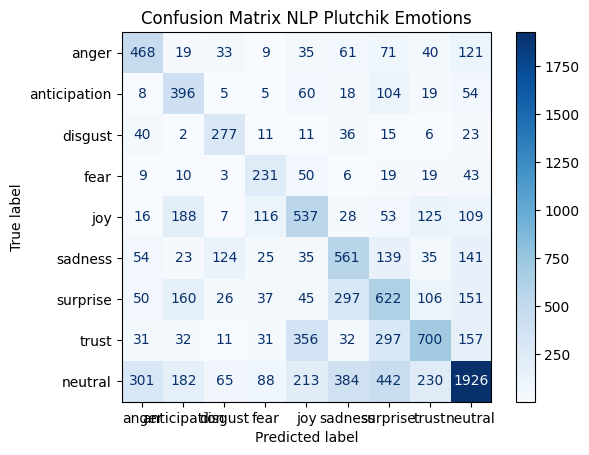

In [12]:
pred = trainer.predict(encoded_dataset["test"])
preds = pred.predictions[1].argmax(-1)
print(classification_report(encoded_dataset['test']['labels'], preds, target_names=list(label2id.keys())))

# Compute the confusion matrix
cm = confusion_matrix(encoded_dataset['test']['labels'], preds)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(label2id.keys()))
disp.plot(cmap=plt.cm.Blues)

plt.title("Confusion Matrix NLP Plutchik Emotions")
plt.show()

In [13]:
def predict_with_confidence(text, model,id2label:dict, threshold = 0.5, device = 'cuda'):
    """
    Take string and predict with confidence what percentage each phrase falls into each label. Enocde exiting ids back to labels
    """
    inputs = tokenizer(text, return_tensors="pt").to(device)
    outputs = model(**inputs)
    probs = F.sigmoid(outputs.logits)

    # Replace below threshold with 0
    probs = torch.where(probs >= threshold, probs, torch.tensor(0.0))

    # Reencode with labels
    label_prob = {}
    for i in range(len(probs[0])):
      label_prob[id2label[i]] = float(probs[0][i])

    return label_prob

text = "Yay me! Except not? Idk what to write here oops. I made a model!"
confidence_scores = predict_with_confidence(text, model,id2label)
print(confidence_scores)  # List of confidence percentages

{'anger': 0.0, 'anticipation': 0.8054792284965515, 'disgust': 0.0, 'fear': 0.0, 'joy': 0.5208771824836731, 'sadness': 0.0, 'surprise': 0.7742421627044678, 'trust': 0.5721849799156189, 'neutral': 0.6681228280067444}


# Exporting

In [14]:
# # Save Folders
trainer.save_model("Plutchik_Model_v1/")
tokenizer.save_pretrained("Plutchick_Model_Tokenizer_v1/")

In [15]:
# Zip files
!zip -r Plutchik_Model_v1.zip Plutchik_Model_v1/
!zip -r Plutchick_Model_Tokenizer_v1.zip Plutchick_Model_Tokenizer_v1/

# If working on Collab
from google.colab import files

files.download('Plutchik_Model_v1.zip')
files.download('Plutchick_Model_Tokenizer_v1.zip')